<a href="https://colab.research.google.com/github/ek7anna/AI-TASKS/blob/main/encoders_and_autoencoders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt
import numpy as np

In [7]:
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape((-1, 784))
x_test = x_test.reshape((-1, 784))

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 784)
Testing data shape: (10000, 784)


In [8]:
encoding_dim = 32

input_img = layers.Input(shape=(784,))

encoded = layers.Dense(128, activation="relu")(input_img)
encoded = layers.Dense(encoding_dim, activation="relu")(encoded)

decoded = layers.Dense(128, activation="relu")(encoded)
decoded = layers.Dense(784, activation="sigmoid")(decoded)

autoencoder = Model(input_img, decoded)

In [9]:
autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,968 (820.19 KB)

 Trainable params: 209,968 (820.19 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = autoencoder.fit(
    x_train,
    x_train,
    epochs=5,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - loss: 0.2247 - val_loss: 0.1455
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1312 - val_loss: 0.1180
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1138 - val_loss: 0.1082
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.1061 - val_loss: 0.1017
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.1014 - val_loss: 0.0985


In [11]:
decoded_imgs = autoencoder.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


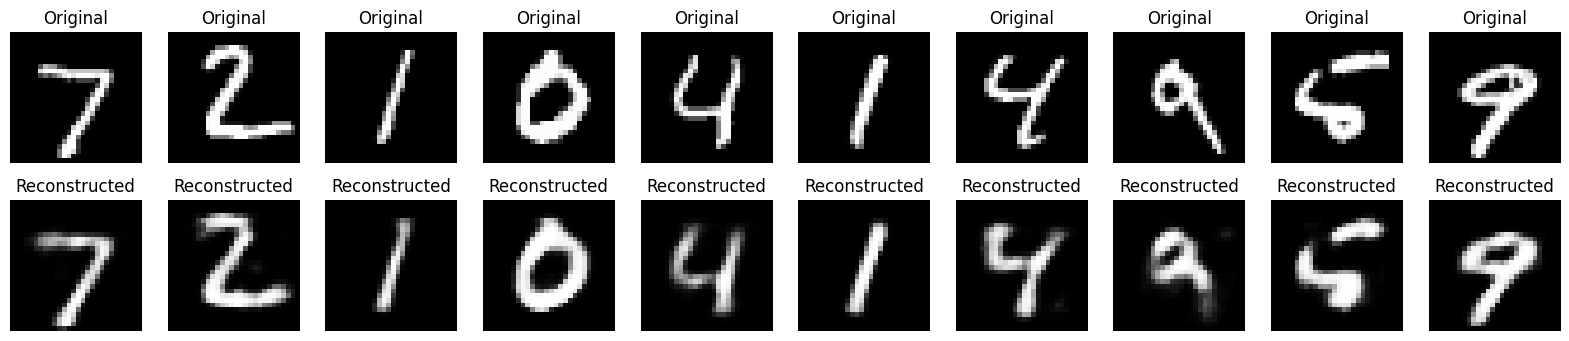

In [12]:
import matplotlib.pyplot as plt

n = 10

plt.figure(figsize=(20,4))

for i in range(n):

    # Original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Reconstructed image
    ax = plt.subplot(2, n, i + n + 1)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis("off")

plt.show()

In [13]:
loss = autoencoder.evaluate(x_test, x_test)

print("Test Loss:", loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0985
Test Loss: 0.09849219024181366


In [14]:
from tensorflow.keras import regularizers

encoding_dim = 32

input_img = layers.Input(shape=(784,))

# Sparse Encoder
encoded = layers.Dense(
    128,
    activation='relu',
    activity_regularizer=regularizers.l1(1e-4)
)(input_img)

encoded = layers.Dense(encoding_dim, activation='relu')(encoded)

# Decoder
decoded = layers.Dense(128, activation='relu')(encoded)
decoded = layers.Dense(784, activation='sigmoid')(decoded)

sparse_autoencoder = Model(input_img, decoded)

In [15]:
sparse_autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

sparse_autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,968 (820.19 KB)

 Trainable params: 209,968 (820.19 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = sparse_autoencoder.fit(
    x_train,
    x_train,
    epochs=5,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.3583 - val_loss: 0.2575
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.2536 - val_loss: 0.2499
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.2484 - val_loss: 0.2471
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 0.2465 - val_loss: 0.2458
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.2456 - val_loss: 0.2450


In [17]:
decoded_imgs = sparse_autoencoder.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


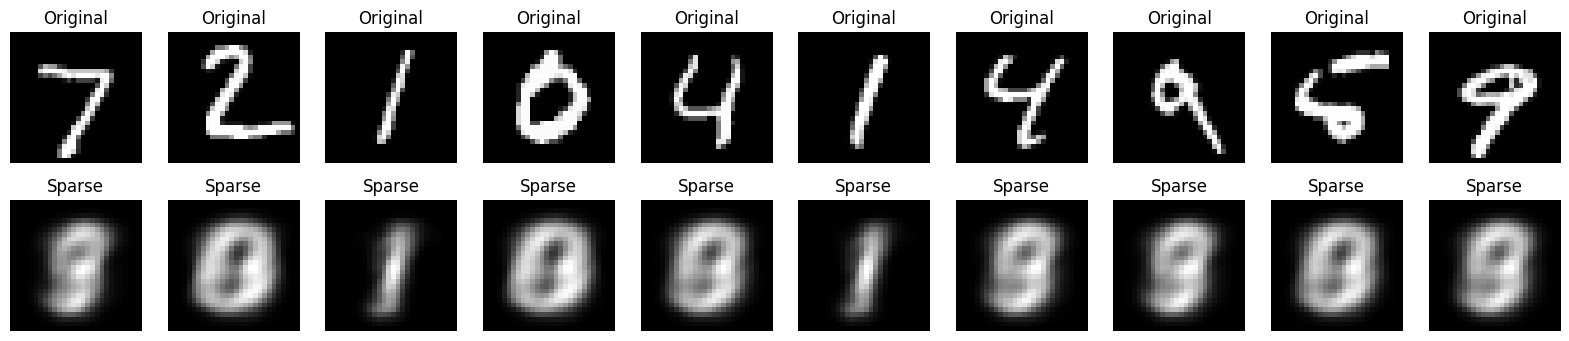

In [18]:
import matplotlib.pyplot as plt

n = 10

plt.figure(figsize=(20,4))

for i in range(n):

    plt.subplot(2,n,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(2,n,i+n+1)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Sparse")
    plt.axis('off')

plt.show()

In [19]:
from tensorflow.keras import backend as K
from tensorflow.keras import losses

In [20]:
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [21]:
latent_dim = 16

encoder_inputs = layers.Input(shape=(784,))

x = layers.Dense(128, activation="relu")(encoder_inputs)

z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

z = Sampling()([z_mean, z_log_var])

encoder = Model(
    encoder_inputs,
    [z_mean, z_log_var, z],
    name="encoder"
)

encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 128)       │    100,480 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 16)        │      2,064 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 16)        │      2,064 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 16)        │          0 │ dense_9[0][0],    │
│                     │                   │            │ dense_10[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 104,608 (408.62 KB)

 Trainable params: 104,608 (408.62 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
latent_inputs = layers.Input(shape=(latent_dim,))

x = layers.Dense(128, activation="relu")(latent_inputs)

decoder_outputs = layers.Dense(
    784,
    activation="sigmoid"
)(x)

decoder = Model(
    latent_inputs,
    decoder_outputs,
    name="decoder"
)

decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 103,312 (403.56 KB)

 Trainable params: 103,312 (403.56 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
class VAE(Model):
    def __init__(self, encoder, decoder):
        super(VAE, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):

        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:

            z_mean, z_log_var, z = self.encoder(data, training=True)
            reconstruction = self.decoder(z, training=True)

            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(data, reconstruction),
                    axis=-1
                )
            )

            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var
                    - tf.square(z_mean)
                    - tf.exp(z_log_var),
                    axis=1
                )
            )

            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        return {
            "loss": total_loss,
            "reconstruction_loss": reconstruction_loss,
            "kl_loss": kl_loss,
        }

In [24]:
vae = VAE(encoder, decoder)

vae.compile(optimizer="adam")

In [25]:
vae.fit(
    x_train,
    epochs=5,
    batch_size=256
)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - kl_loss: 6.3884 - loss: 27.4268 - reconstruction_loss: 21.0384
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - kl_loss: 8.4016 - loss: 25.3164 - reconstruction_loss: 16.9148
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - kl_loss: 9.0998 - loss: 24.9821 - reconstruction_loss: 15.8823
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - kl_loss: 8.9774 - loss: 24.7963 - reconstruction_loss: 15.8189
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - kl_loss: 9.6354 - loss: 24.6494 - reconstruction_loss: 15.0140


In [26]:
# Encode test images
z_mean, z_log_var, z = encoder.predict(x_test)

# Decode latent vectors
decoded_imgs = decoder.predict(z)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


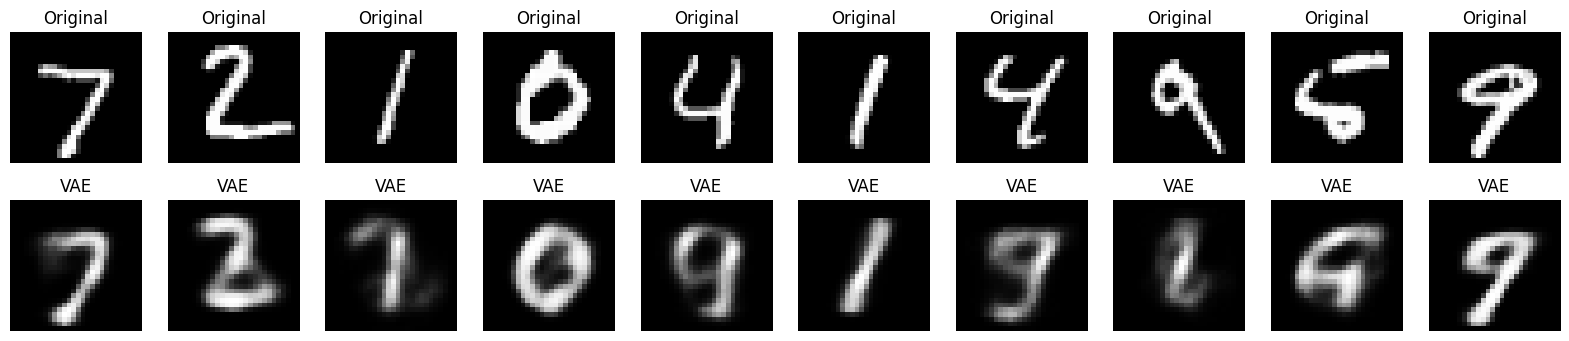

In [27]:
import matplotlib.pyplot as plt

n = 10

plt.figure(figsize=(20,4))

for i in range(n):

    # Original
    plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28,28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Reconstructed
    plt.subplot(2, n, i + n + 1)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap="gray")
    plt.title("VAE")
    plt.axis("off")

plt.show()

In [28]:
latent_dim = 32

encoder_input = layers.Input(shape=(784,))

x = layers.Dense(256, activation="relu")(encoder_input)
x = layers.Dense(128, activation="relu")(x)

latent = layers.Dense(latent_dim, name="latent_vector")(x)

encoder = Model(encoder_input, latent, name="Encoder")

encoder.summary()

Model: "Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_vector (Dense)           │ (None, 32)             │         4,128 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 237,984 (929.62 KB)

 Trainable params: 237,984 (929.62 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
decoder_input = layers.Input(shape=(latent_dim,))

x = layers.Dense(128, activation="relu")(decoder_input)
x = layers.Dense(256, activation="relu")(x)

decoder_output = layers.Dense(784, activation="sigmoid")(x)

decoder = Model(decoder_input, decoder_output, name="Decoder")

decoder.summary()

Model: "Decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 238,736 (932.56 KB)

 Trainable params: 238,736 (932.56 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
img = layers.Input(shape=(784,))

encoded = encoder(img)
decoded = decoder(encoded)

autoencoder = Model(img, decoded, name="AAE_Autoencoder")

autoencoder.summary()

Model: "AAE_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder (Functional)            │ (None, 32)             │       237,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder (Functional)            │ (None, 784)            │       238,736 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 476,720 (1.82 MB)

 Trainable params: 476,720 (1.82 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
disc_input = layers.Input(shape=(latent_dim,))

x = layers.Dense(64, activation="relu")(disc_input)
x = layers.Dense(32, activation="relu")(x)

disc_output = layers.Dense(1, activation="sigmoid")(x)

discriminator = Model(disc_input, disc_output, name="Discriminator")

discriminator.summary()

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,225 (16.50 KB)

 Trainable params: 4,225 (16.50 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
# Autoencoder
autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

# Discriminator
discriminator.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [33]:
real = np.ones((256, 1))
fake = np.zeros((256, 1))

In [34]:
batch_size = 256

real = np.ones((batch_size, 1))
fake = np.zeros((batch_size, 1))

In [35]:
from tensorflow.keras.models import Model

In [36]:
class AdversarialAutoencoder(Model):
    def __init__(self, encoder, decoder, discriminator):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.discriminator = discriminator

        self.reconstruction_loss_fn = tf.keras.losses.BinaryCrossentropy()
        self.adversarial_loss_fn = tf.keras.losses.BinaryCrossentropy()

    def compile(self, ae_optimizer, disc_optimizer):
        super().compile()

        self.ae_optimizer = ae_optimizer
        self.disc_optimizer = disc_optimizer

    def train_step(self, data):

        if isinstance(data, tuple):
            data = data[0]

        batch_size = tf.shape(data)[0]

        # -----------------------------
        # 1. Train Autoencoder
        # -----------------------------
        with tf.GradientTape() as tape:

            latent = self.encoder(data, training=True)
            reconstruction = self.decoder(latent, training=True)

            recon_loss = self.reconstruction_loss_fn(data, reconstruction)

        grads = tape.gradient(
            recon_loss,
            self.encoder.trainable_weights +
            self.decoder.trainable_weights
        )

        self.ae_optimizer.apply_gradients(
            zip(
                grads,
                self.encoder.trainable_weights +
                self.decoder.trainable_weights
            )
        )

        # -----------------------------
        # 2. Train Discriminator
        # -----------------------------
        real_latent = tf.random.normal((batch_size, latent_dim))
        fake_latent = self.encoder(data, training=False)

        with tf.GradientTape() as tape:

            real_pred = self.discriminator(real_latent, training=True)
            fake_pred = self.discriminator(fake_latent, training=True)

            d_loss_real = self.adversarial_loss_fn(
                tf.ones_like(real_pred),
                real_pred
            )

            d_loss_fake = self.adversarial_loss_fn(
                tf.zeros_like(fake_pred),
                fake_pred
            )

            d_loss = d_loss_real + d_loss_fake

        grads = tape.gradient(
            d_loss,
            self.discriminator.trainable_weights
        )

        self.disc_optimizer.apply_gradients(
            zip(grads, self.discriminator.trainable_weights)
        )

        # -----------------------------
        # 3. Train Encoder to Fool
        # -----------------------------
        with tf.GradientTape() as tape:

            fake_latent = self.encoder(data, training=True)

            prediction = self.discriminator(
                fake_latent,
                training=False
            )

            adv_loss = self.adversarial_loss_fn(
                tf.ones_like(prediction),
                prediction
            )

        grads = tape.gradient(
            adv_loss,
            self.encoder.trainable_weights
        )

        self.ae_optimizer.apply_gradients(
            zip(grads, self.encoder.trainable_weights)
        )

        return {
            "reconstruction_loss": recon_loss,
            "discriminator_loss": d_loss,
            "adversarial_loss": adv_loss
        }

In [37]:
aae = AdversarialAutoencoder(
    encoder,
    decoder,
    discriminator
)

aae.compile(
    ae_optimizer=tf.keras.optimizers.Adam(),
    disc_optimizer=tf.keras.optimizers.Adam()
)

In [38]:
history = aae.fit(
    x_train,
    epochs=5,
    batch_size=256
)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - adversarial_loss: 0.7281 - discriminator_loss: 2.5359 - reconstruction_loss: 0.2728
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - adversarial_loss: 0.5738 - discriminator_loss: 1.8799 - reconstruction_loss: 0.2419
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - adversarial_loss: 0.5823 - discriminator_loss: 1.6555 - reconstruction_loss: 0.2333
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - adversarial_loss: 0.5802 - discriminator_loss: 1.5728 - reconstruction_loss: 0.2082
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - adversarial_loss: 0.6082 - discriminator_loss: 1.5432 - reconstruction_loss: 0.2146


In [39]:
# Encode test images
latent = encoder.predict(x_test)

# Decode them
decoded_imgs = decoder.predict(latent)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


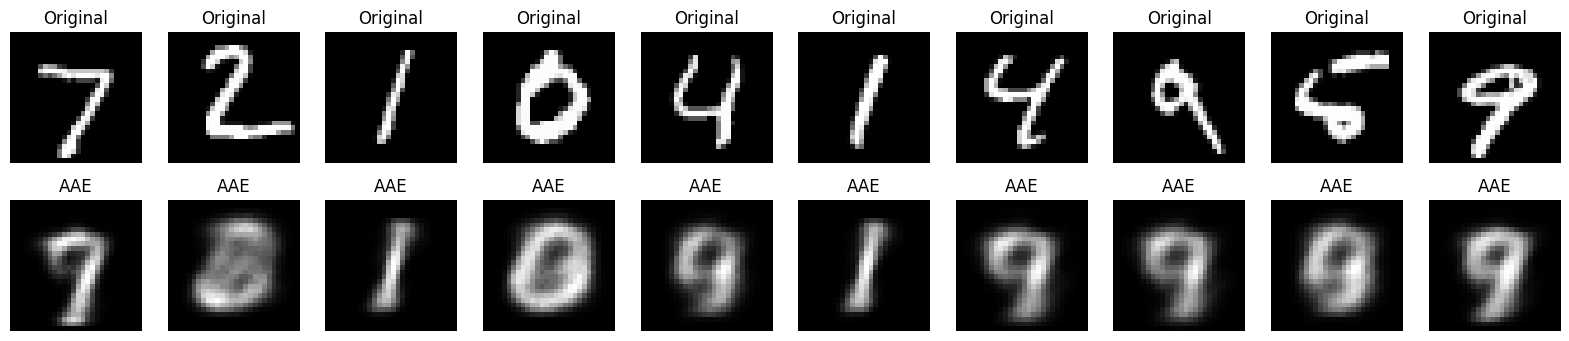

In [40]:
import matplotlib.pyplot as plt

n = 10
plt.figure(figsize=(20,4))

for i in range(n):

    # Original
    plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    plt.subplot(2, n, i + n + 1)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("AAE")
    plt.axis('off')

plt.show()

In [41]:
latent_dim = 32

inputs = layers.Input(shape=(784,))

# Encoder
x = layers.Dense(256, activation="relu")(inputs)

# Attention
attention = layers.Dense(
    256,
    activation="softmax",
    name="attention_weights"
)(x)

x = layers.Multiply()([x, attention])

# Bottleneck
latent = layers.Dense(latent_dim, activation="relu")(x)

# Decoder
x = layers.Dense(256, activation="relu")(latent)

outputs = layers.Dense(
    784,
    activation="sigmoid"
)(x)

attention_autoencoder = Model(
    inputs,
    outputs,
    name="Attention_Autoencoder"
)

attention_autoencoder.summary()

Model: "Attention_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 256)       │    200,960 │ input_layer_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_weights   │ (None, 256)       │     65,792 │ dense_21[0][0]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 256)       │          0 │ dense_21[0][0],   │
│                     │                   │            │ attention_weight… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 32)        │      8,224 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 256)       │      8,448 │ dense_22[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 784)       │    201,488 │ dense_23[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 484,912 (1.85 MB)

 Trainable params: 484,912 (1.85 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
attention_autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

In [43]:
history = attention_autoencoder.fit(
    x_train,
    x_train,
    epochs=5,
    batch_size=256,
    validation_data=(x_test, x_test)
)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - loss: 0.3295 - val_loss: 0.2574
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 0.2499 - val_loss: 0.2462
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.2457 - val_loss: 0.2445
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 0.2344 - val_loss: 0.2130
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - loss: 0.2051 - val_loss: 0.1999


In [44]:
decoded_imgs = attention_autoencoder.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


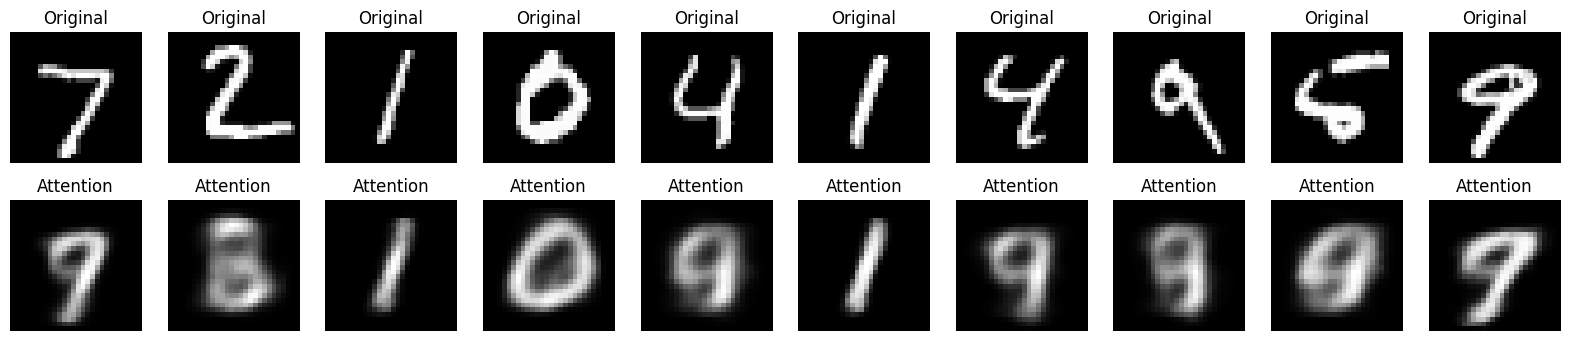

In [45]:
import matplotlib.pyplot as plt

n = 10

plt.figure(figsize=(20,4))

for i in range(n):

    plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28,28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2, n, i + n + 1)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap="gray")
    plt.title("Attention")
    plt.axis("off")

plt.show()

In [46]:
latent_dim = 32

inputs = layers.Input(shape=(784,))

# Adaptive Encoder
x = layers.Dense(256, activation="relu")(inputs)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)

x = layers.Dense(128, activation="relu")(x)
latent = layers.Dense(latent_dim, activation="relu")(x)

# Decoder
x = layers.Dense(128, activation="relu")(latent)
x = layers.Dense(256, activation="relu")(x)

outputs = layers.Dense(784, activation="sigmoid")(x)

adaptive_autoencoder = Model(
    inputs,
    outputs,
    name="Adaptive_Autoencoder"
)

adaptive_autoencoder.summary()

Model: "Adaptive_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 477,744 (1.82 MB)

 Trainable params: 477,232 (1.82 MB)

 Non-trainable params: 512 (2.00 KB)

In [47]:
adaptive_autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

In [48]:
history = adaptive_autoencoder.fit(
    x_train,
    x_train,
    epochs=5,
    batch_size=256,
    validation_data=(x_test, x_test)
)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - loss: 0.1895 - val_loss: 0.1353
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 0.1232 - val_loss: 0.1099
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - loss: 0.1125 - val_loss: 0.1037
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 0.1074 - val_loss: 0.0986
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.1038 - val_loss: 0.0954


In [49]:
decoded_imgs = adaptive_autoencoder.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


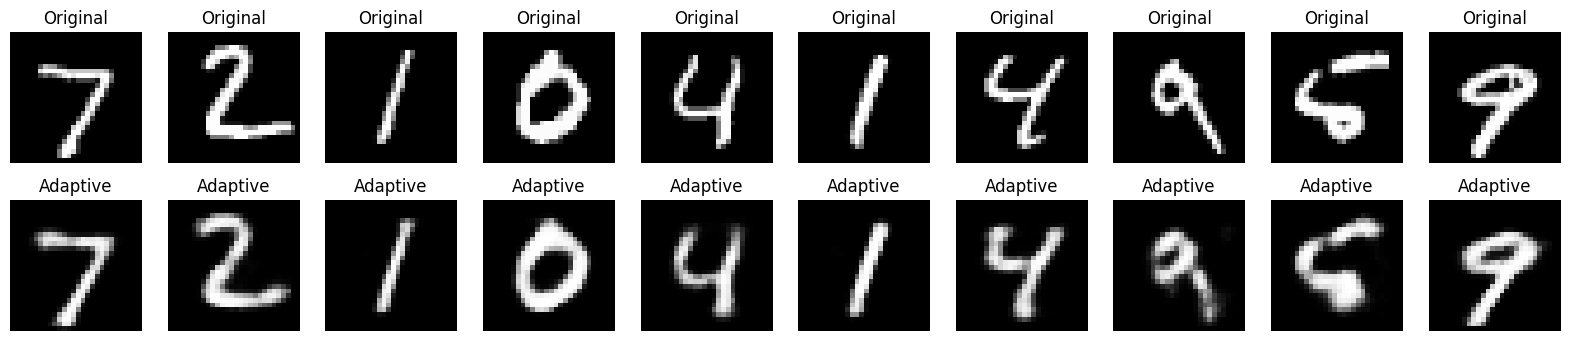

In [50]:
import matplotlib.pyplot as plt

n = 10

plt.figure(figsize=(20,4))

for i in range(n):

    plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28,28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2, n, i + n + 1)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap="gray")
    plt.title("Adaptive")
    plt.axis("off")

plt.show()